In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [52]:
# Load datasets
oscars = pd.read_csv("the_oscar_award.csv")
imdb = pd.read_csv("movie_metadata.csv")

print("Oscar dataset shape:", oscars.shape)
print("IMDb dataset shape:", imdb.shape)


Oscar dataset shape: (11110, 8)
IMDb dataset shape: (5043, 28)


In [53]:
oscars.head()

,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner
0,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Noose,False
1,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Patent Leather Kid,False
2,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Last Command,True
3,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Way of All Flesh,True
4,1927,1928,1,ACTRESS,ACTRESS IN A LEADING ROLE,Louise Dresser,A Ship Comes In,False


In [54]:
imdb.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [55]:
oscars.columns

Index(['year_film', 'year_ceremony', 'ceremony', 'category', 'canon_category',
       'name', 'film', 'winner'],
      dtype='object')

In [56]:
imdb.columns


Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

In [57]:
# Remove extra spaces & lowercase movie titles in Oscar dataset
oscars['film'] = oscars['film'].str.strip().str.lower()

# Preview
oscars[['film', 'winner']].head()

,film,winner
0,the noose,False
1,the patent leather kid,False
2,the last command,True
3,the way of all flesh,True
4,a ship comes in,False


In [58]:
# Remove extra spaces & lowercase movie titles in IMDb dataset
imdb['movie_title'] = imdb['movie_title'].str.strip().str.lower()

# Preview
imdb[['movie_title', 'imdb_score', 'budget']].head()

,movie_title,imdb_score,budget
0,avatar,7.9,237000000.0
1,pirates of the caribbean: at world's end,7.1,300000000.0
2,spectre,6.8,245000000.0
3,the dark knight rises,8.5,250000000.0
4,star wars: episode vii - the force awakens,7.1,NaN


In [59]:
# Check missing values
imdb.isna().sum()

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
movie_imdb_link                0
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64

In [60]:
# Drop rows with missing critical info
imdb = imdb.dropna(subset=['budget', 'duration', 'title_year'])

# Quick check
print("IMDb dataset shape after dropping critical NaNs:", imdb.shape)

IMDb dataset shape after dropping critical NaNs: (4538, 28)


In [61]:
oscars.isna().sum()

year_film           0
year_ceremony       0
ceremony            0
category            0
canon_category      0
name                7
film              359
winner              0
dtype: int64

In [62]:
# Drop rows with missing movie titles
oscars = oscars.dropna(subset=['film'])

# Quick check
print("Oscar dataset shape after dropping missing films:", oscars.shape)

Oscar dataset shape after dropping missing films: (10751, 8)


In [63]:
# Merge datasets on movie title and year
merged_data = pd.merge(
    oscars,
    imdb,
    left_on=['film', 'year_film'],
    right_on=['movie_title', 'title_year'],
    how='left'
)

# Quick check
print("Merged dataset shape:", merged_data.shape)
merged_data.head()


Merged dataset shape: (10828, 36)


,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner,color,director_name,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,the noose,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,the patent leather kid,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,the last command,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,the way of all flesh,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1927,1928,1,ACTRESS,ACTRESS IN A LEADING ROLE,Louise Dresser,a ship comes in,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
merged_data = merged_data.dropna(subset=['budget', 'duration', 'imdb_score'])


In [65]:
merged_data[['film','movie_title','budget','imdb_score','winner']].head(10)


,film,movie_title,budget,imdb_score,winner
216,a farewell to arms,a farewell to arms,800000.0,6.6,False
218,a farewell to arms,a farewell to arms,800000.0,6.6,True
225,a farewell to arms,a farewell to arms,800000.0,6.6,False
243,a farewell to arms,a farewell to arms,800000.0,6.6,True
253,it happened one night,it happened one night,325000.0,8.2,True
256,it happened one night,it happened one night,325000.0,8.2,True
269,it happened one night,it happened one night,325000.0,8.2,True
288,it happened one night,it happened one night,325000.0,8.2,True
310,it happened one night,it happened one night,325000.0,8.2,True
329,top hat,top hat,609000.0,7.8,False


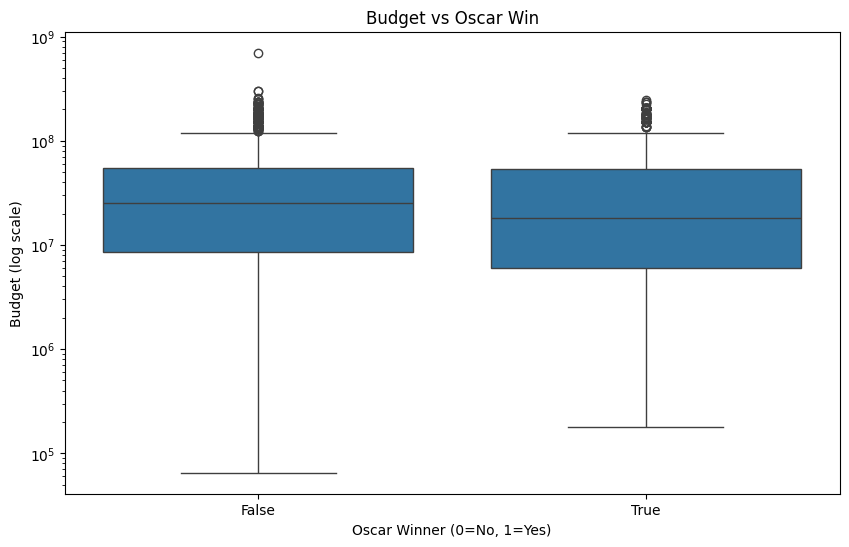

In [66]:
# Budget vs Oscar win
plt.figure(figsize=(10,6))
sns.boxplot(x='winner', y='budget', data=merged_data)
plt.yscale('log')  # budget varies widely, use log scale
plt.title('Budget vs Oscar Win')
plt.xlabel('Oscar Winner (0=No, 1=Yes)')
plt.ylabel('Budget (log scale)')
plt.show()


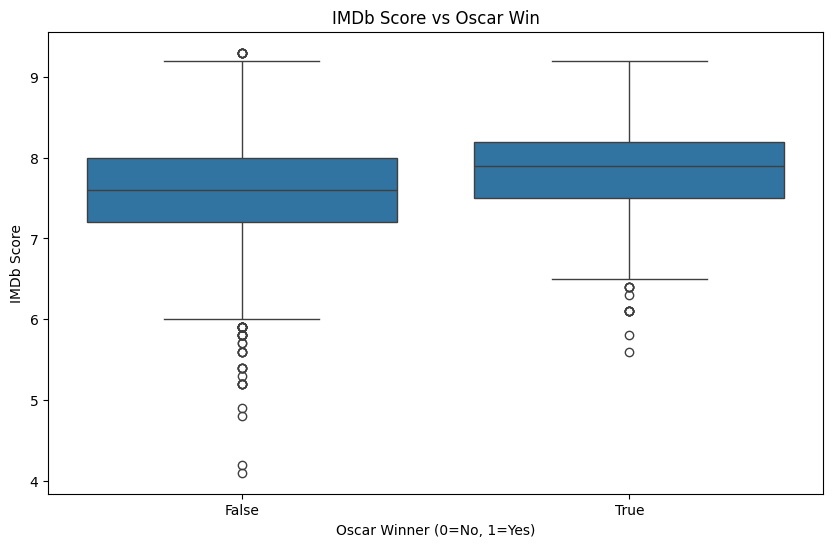

In [67]:
plt.figure(figsize=(10,6))
sns.boxplot(x='winner', y='imdb_score', data=merged_data)
plt.title('IMDb Score vs Oscar Win')
plt.xlabel('Oscar Winner (0=No, 1=Yes)')
plt.ylabel('IMDb Score')
plt.show()


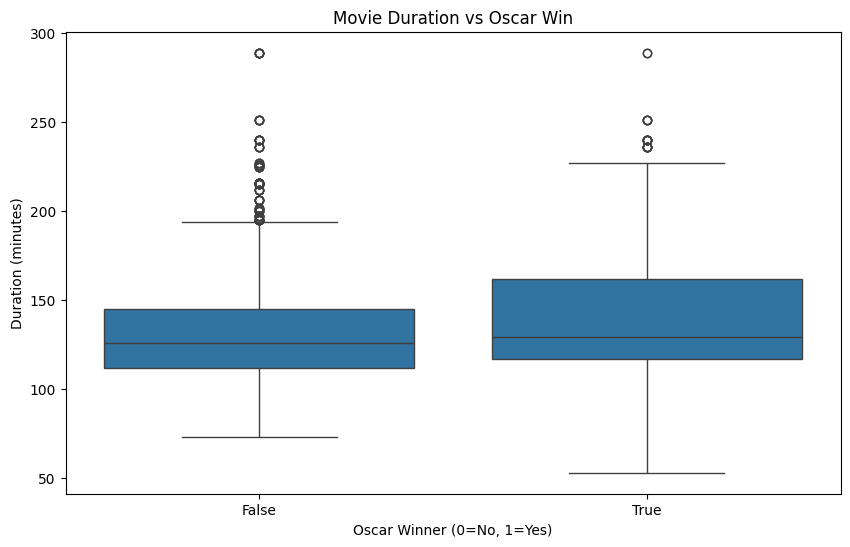

In [68]:
plt.figure(figsize=(10,6))
sns.boxplot(x='winner', y='duration', data=merged_data)
plt.title('Movie Duration vs Oscar Win')
plt.xlabel('Oscar Winner (0=No, 1=Yes)')
plt.ylabel('Duration (minutes)')
plt.show()


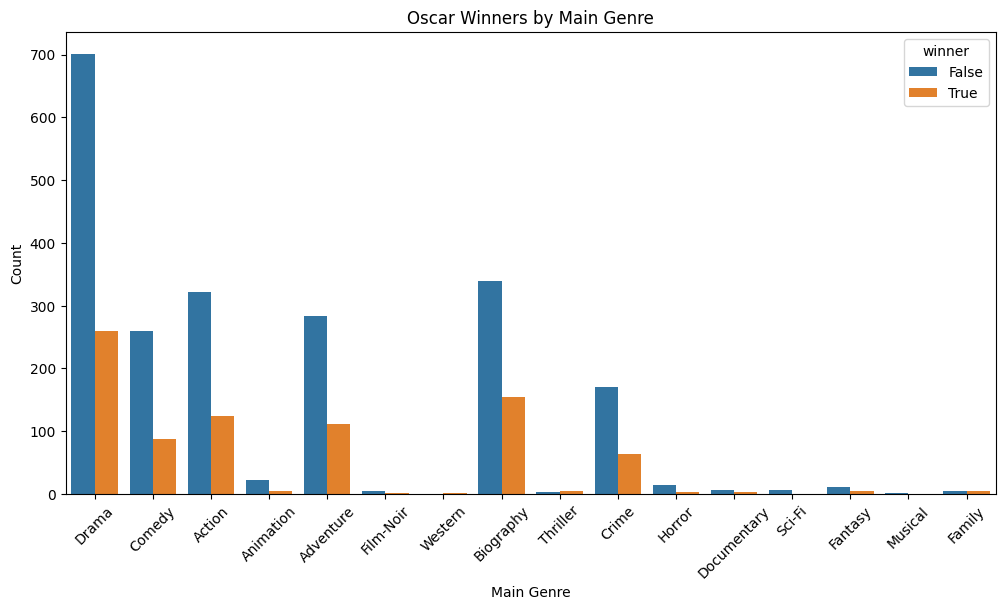

In [69]:
# Split genres (some movies have multiple genres separated by '|')
merged_data['main_genre'] = merged_data['genres'].str.split('|').str[0]

plt.figure(figsize=(12,6))
sns.countplot(x='main_genre', hue='winner', data=merged_data)
plt.title('Oscar Winners by Main Genre')
plt.xlabel('Main Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


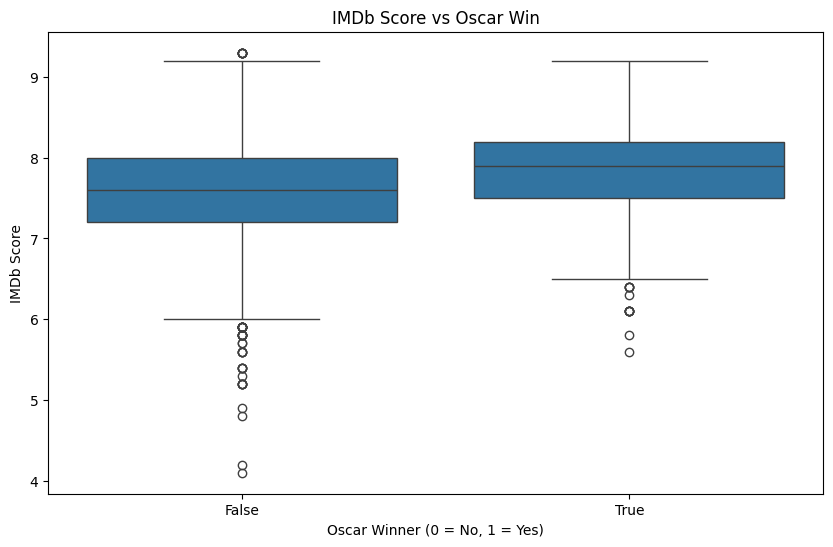

In [70]:
plt.figure(figsize=(10,6))
sns.boxplot(x='winner', y='imdb_score', data=merged_data)
plt.title('IMDb Score vs Oscar Win')
plt.xlabel('Oscar Winner (0 = No, 1 = Yes)')
plt.ylabel('IMDb Score')
plt.show()


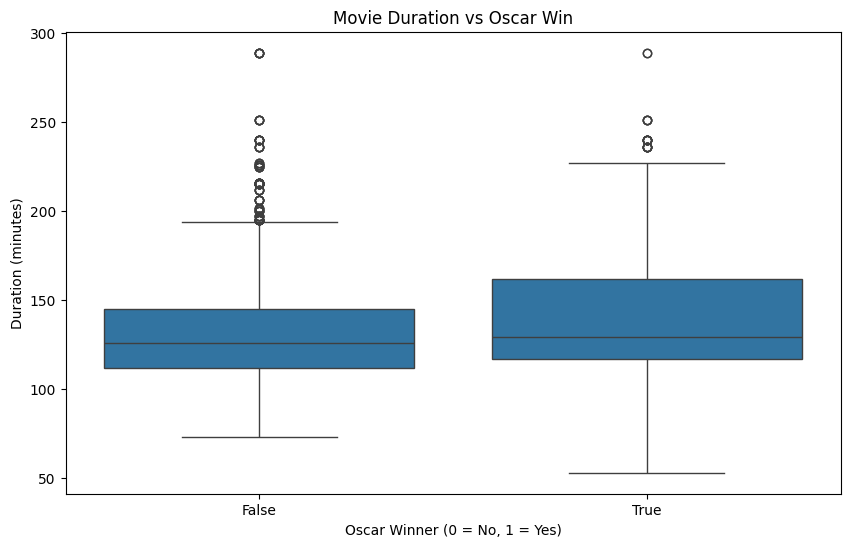

In [71]:
plt.figure(figsize=(10,6))
sns.boxplot(x='winner', y='duration', data=merged_data)
plt.title('Movie Duration vs Oscar Win')
plt.xlabel('Oscar Winner (0 = No, 1 = Yes)')
plt.ylabel('Duration (minutes)')
plt.show()


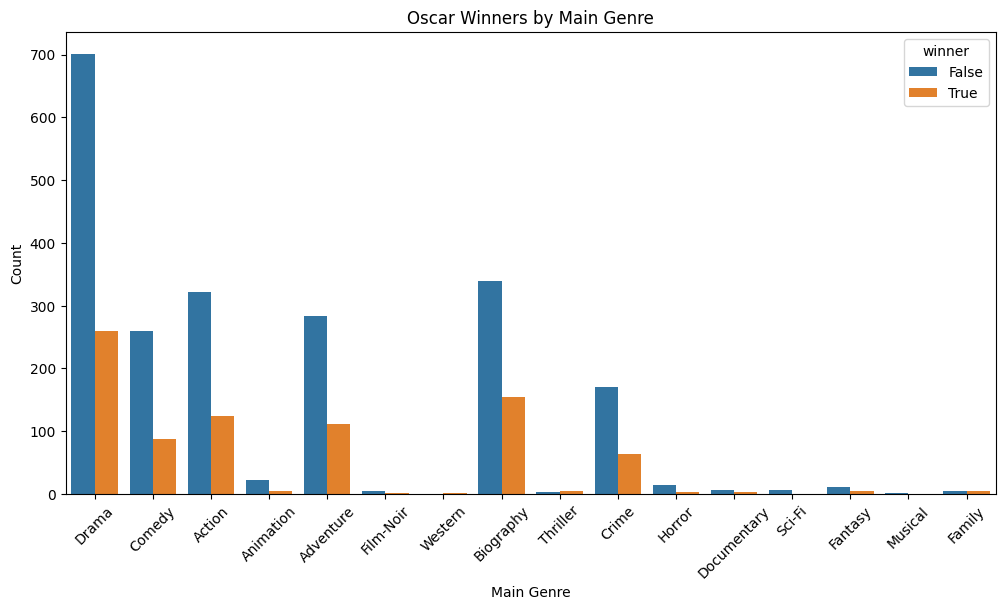

In [72]:
# Extract main genre
merged_data['main_genre'] = merged_data['genres'].str.split('|').str[0]

plt.figure(figsize=(12,6))
sns.countplot(
    x='main_genre',
    hue='winner',
    data=merged_data
)

plt.title('Oscar Winners by Main Genre')
plt.xlabel('Main Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [73]:
# Select required columns for ML
ml_data = merged_data[
    [
        'winner',
        'imdb_score',
        'budget',
        'duration',
        'title_year',
        'main_genre',
        'country'
    ]
].copy()

# Drop rows with missing values in these columns
ml_data = ml_data.dropna()

print("ML data shape:", ml_data.shape)
ml_data.head()


ML data shape: (2979, 7)


,winner,imdb_score,budget,duration,title_year,main_genre,country
216,False,6.6,800000.0,79.0,1932.0,Drama,USA
218,True,6.6,800000.0,79.0,1932.0,Drama,USA
225,False,6.6,800000.0,79.0,1932.0,Drama,USA
243,True,6.6,800000.0,79.0,1932.0,Drama,USA
253,True,8.2,325000.0,65.0,1934.0,Comedy,USA


In [74]:

# Log transform budget to reduce skewness
ml_data['log_budget'] = np.log1p(ml_data['budget'])

# Check result
ml_data[['budget', 'log_budget']].head()

,budget,log_budget
216,800000.0,13.592368
218,800000.0,13.592368
225,800000.0,13.592368
243,800000.0,13.592368
253,325000.0,12.691584


In [75]:

# One-hot encode main_genre
genre_dummies = pd.get_dummies(ml_data['main_genre'], prefix='genre')

# Add to ml_data
ml_data = pd.concat([ml_data, genre_dummies], axis=1)

# Drop original genre column
ml_data = ml_data.drop(columns=['main_genre'])

print("ML data shape after genre encoding:", ml_data.shape)
ml_data.head()


ML data shape after genre encoding: (2979, 23)


,winner,imdb_score,budget,duration,title_year,country,log_budget,genre_Action,genre_Adventure,genre_Animation,...,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_Musical,genre_Sci-Fi,genre_Thriller,genre_Western
216,False,6.6,800000.0,79.0,1932.0,USA,13.592368,False,False,False,...,False,True,False,False,False,False,False,False,False,False
218,True,6.6,800000.0,79.0,1932.0,USA,13.592368,False,False,False,...,False,True,False,False,False,False,False,False,False,False
225,False,6.6,800000.0,79.0,1932.0,USA,13.592368,False,False,False,...,False,True,False,False,False,False,False,False,False,False
243,True,6.6,800000.0,79.0,1932.0,USA,13.592368,False,False,False,...,False,True,False,False,False,False,False,False,False,False
253,True,8.2,325000.0,65.0,1934.0,USA,12.691584,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [76]:
# Check top countries
ml_data['country'].value_counts().head(10)


country
USA            2364
UK              383
France           69
New Zealand      35
Australia        31
Germany          15
Spain            15
China            13
Canada           11
Taiwan           10
Name: count, dtype: int64

In [77]:

# Keep top 5 countries
top_countries = ml_data['country'].value_counts().head(5).index

ml_data['country_clean'] = ml_data['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)


In [78]:

# One-hot encode country
country_dummies = pd.get_dummies(ml_data['country_clean'], prefix='country')

ml_data = pd.concat([ml_data, country_dummies], axis=1)

# Drop original country columns
ml_data = ml_data.drop(columns=['country', 'country_clean'])

print("ML data shape after country encoding:", ml_data.shape)
ml_data.head()


ML data shape after country encoding: (2979, 28)


,winner,imdb_score,budget,duration,title_year,log_budget,genre_Action,genre_Adventure,genre_Animation,genre_Biography,...,genre_Musical,genre_Sci-Fi,genre_Thriller,genre_Western,country_Australia,country_France,country_New Zealand,country_Other,country_UK,country_USA
216,False,6.6,800000.0,79.0,1932.0,13.592368,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
218,True,6.6,800000.0,79.0,1932.0,13.592368,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
225,False,6.6,800000.0,79.0,1932.0,13.592368,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
243,True,6.6,800000.0,79.0,1932.0,13.592368,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
253,True,8.2,325000.0,65.0,1934.0,12.691584,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [79]:
# Drop columns not needed for ML
ml_data = ml_data.drop(columns=['budget'])

# Separate features and target
X = ml_data.drop(columns=['winner'])
y = ml_data['winner']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (2979, 26)
Target shape: (2979,)


In [80]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (2383, 26)
Testing set shape: (596, 26)


In [81]:
from sklearn.linear_model import LogisticRegression

# Create and train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")



Logistic Regression model trained successfully


C:\Users\PMLS\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [82]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed")


Data scaling completed


In [83]:
# Train Logistic Regression again on scaled data
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully (scaled data)")


Logistic Regression trained successfully (scaled data)


In [84]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = log_model.predict(X_test_scaled)

print("Predictions completed")


Predictions completed


In [85]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7114093959731543


In [86]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[416  15]
 [157   8]]


In [87]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

       False       0.73      0.97      0.83       431
        True       0.35      0.05      0.09       165

    accuracy                           0.71       596
   macro avg       0.54      0.51      0.46       596
weighted avg       0.62      0.71      0.62       596



In [88]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")


Random Forest model trained successfully


In [89]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict using Random Forest
y_pred_rf = rf_model.predict(X_test)

print("Predictions completed")


Predictions completed


In [90]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)


Random Forest Accuracy: 0.6610738255033557


In [91]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)


Confusion Matrix:
[[303 128]
 [ 74  91]]


In [92]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.70      0.75       431
        True       0.42      0.55      0.47       165

    accuracy                           0.66       596
   macro avg       0.61      0.63      0.61       596
weighted avg       0.70      0.66      0.67       596



In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp.head(10)


,Feature,Importance
1,duration,0.221554
0,imdb_score,0.218168
2,title_year,0.204298
3,log_budget,0.197669
11,genre_Drama,0.017407
7,genre_Biography,0.016501
25,country_USA,0.015069
4,genre_Action,0.014999
8,genre_Comedy,0.014070
5,genre_Adventure,0.014036


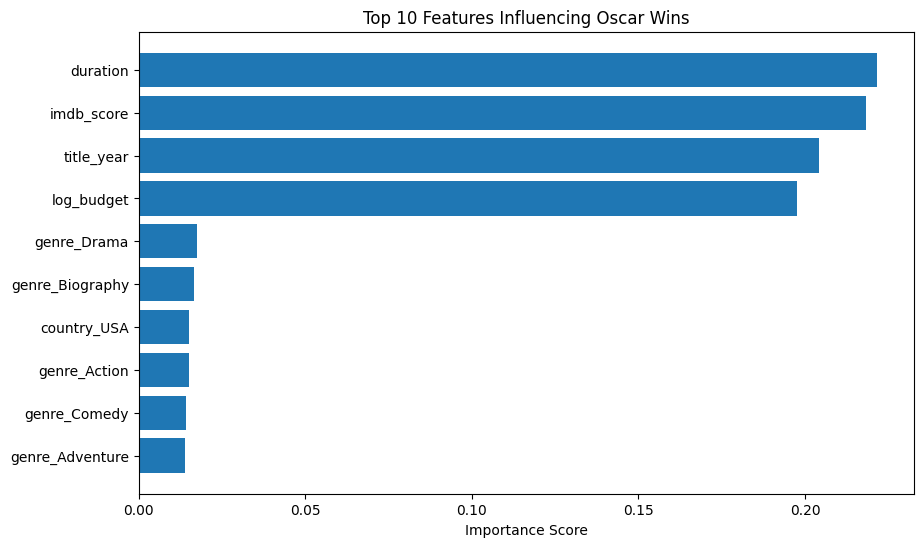

In [94]:
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"].head(10), feat_imp["Importance"].head(10))
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Features Influencing Oscar Wins")
plt.show()


In [95]:
import pickle

# Save the trained Random Forest model
pickle.dump(rf_model, open("oscar_model.pkl", "wb"))

print("Model saved successfully as oscar_model.pkl")


Model saved successfully as oscar_model.pkl


In [96]:
pickle.dump(X.columns.tolist(), open("model_features.pkl", "wb"))

print("Feature list saved successfully")


Feature list saved successfully
